# 18_05 — Modelos de referencia · **Escenario B: FAR con signo conmutado** · **barrido en $M$**

Paso **3c**, posterior a `18_04_evaluacion`. Eje 1 de `§03_06`: el PSBPM-FD
contra los modelos de referencia, sobre la misma representación y con el mismo
conjunto de información. Sólo métricas **puntuales**.

| Modelo | Qué es | Referencia |
|---|---|---|
| `VAR` | VAR($p$) sobre los scores, con intercepto | Aue, Norinho & Hörmann (2015) |
| `FAR1` | $\hat\Psi=\hat C_1\hat C_0^{-1}$ en el subespacio FPCA | Bosq (2000) |
| `RF` | bosque aleatorio multisalida | no lineal |
| `GBT` | *gradient boosting* por score | no lineal |
| `media`, `persistencia` | líneas base de `fit/baselines.py` | piso |

Control: FAR(1) lineal, gaussiano y homogéneo. `VAR` y `FAR1` están
correctamente especificados, de modo que empatar con ellos o quedar algo por
detrás es lo esperado, y esa brecha es la cota con la que se leen los demás
escenarios. `RF` y `GBT` deberían perder.

## Por qué el barrido cambia lo que este notebook puede concluir

Con un solo $M$, que el PSBPM-FD quede por detrás del VAR admite dos lecturas
que no se distinguen: *el modelo es peor* o *la representación no le da con qué
ganar*. El barrido las separa, porque **todos los competidores viven sobre la
misma representación**: si al subir $M$ se degradan todos por igual, el
responsable es el truncamiento FPCA y no el modelo; si sólo se degrada el
PSBPM-FD, la hipótesis de la Etapa D —$M$ entra dos veces, y la segunda diluye
el prior de selección de los pesos de la mezcla— queda respaldada.

Ésa es la comparación de la **§8**, y es la razón de ser de esta versión del
notebook.

## 1. Imports, rutas y artefactos

In [1]:
1

1

In [2]:
import sys
import json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor
from model_psbp_fd.fit import (
    rmse_por_coeficiente, r2_por_columna, razon_dispersion,
    mise, rmse_funcional, ventana_movil_funcional,
)
from model_psbp_fd.graphics import plot_ventana_movil
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# == [CONFIG] ================================================================
# BARRIDO EN M. Debe ser el mismo que en 18_01, 18_03, 18_04 y el .m.
# ESCENARIO_ID es una CADENA en esta corrida; el .m usa %s por el mismo motivo.
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", "B", 1
M_FPCA_LIST = (1, 2, 3)
# ============================================================================

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

# Este notebook NO pisa nada de 18_04: los _04 ocupan 50-65 según el escenario,
# éste escribe 70-75 en cada directorio de M, y 90-93 en el del barrido.
PREFIJO = 70

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}   (archivos {PREFIJO}-{PREFIJO+5})")
print(f"salidas cruzadas (§8) : {PATH_BARRIDO}   (archivos 90-93)")

barrido en M : [1, 2, 3]
  M=1  ->  escenario_B_r01_m01   (archivos 70-75)
  M=2  ->  escenario_B_r01_m02   (archivos 70-75)
  M=3  ->  escenario_B_r01_m03   (archivos 70-75)
salidas cruzadas (§8) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_B_r01_barrido_M   (archivos 90-93)


In [4]:
EST, saltados = {}, []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 18_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "standardized_zscore_ddof0"

    objetivo = eval_config.get("objetivo_evaluacion", "curva_verdadera")
    assert objetivo == "curva_verdadera", (
        f"[M={M}] objetivo_evaluacion={objetivo!r}. Este notebook compara "
        "contra la curva verdadera; con otro objetivo las cifras no serían "
        "las del _04.")

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": list(manifest["cov_names"]),
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "objetivo": objetivo,
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40])),
    }

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 18_01 primero."
for M, motivo in saltados:
    print(f"! M={M} saltado: {motivo}")

_comun = {M: (e["T"], e["T0"], e["n_lags"], e["objetivo"], e["modo_residuo"],
              tuple(e["ventanas_w"])) for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    for M, v in _comun.items():
        print(f"  M={M}: {v}")
    raise AssertionError(
        "El barrido exige T, T0, n_lags, objetivo, modo_residuo y ventanas "
        "idénticos entre puntos.")

_M0        = next(iter(EST))
T          = EST[_M0]["T"]
T0         = EST[_M0]["T0"]
N_LAGS     = EST[_M0]["n_lags"]
OBJETIVO   = EST[_M0]["objetivo"]
MODO_RESIDUO = EST[_M0]["modo_residuo"]
VENTANAS_W = EST[_M0]["ventanas_w"]
W_COMP     = VENTANAS_W[len(VENTANAS_W) // 2]

print(f"\nT={T}  T0={T0}  n_lags={N_LAGS}  objetivo={OBJETIVO!r}  "
      f"modo_residuo={MODO_RESIDUO!r}")
print(f"anchos de ventana: {VENTANAS_W}   ·   referencia para las tablas: w={W_COMP}")
for M, e in EST.items():
    print(f"  M={M}: {e['n_components']} componentes · "
          f"{len(e['cov_names'])} covariables {e['cov_names']}")

! M=3 saltado: sin datasets_manifest.json - falta correr 18_01

T=400  T0=280  n_lags=1  objetivo='curva_verdadera'  modo_residuo='ninguno'
anchos de ventana: [10, 20, 40]   ·   referencia para las tablas: w=20
  M=1: 1 componentes · 1 covariables ['fpc_1_lag1']
  M=2: 2 componentes · 2 covariables ['fpc_1_lag1', 'fpc_2_lag1']


In [5]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)         # (T, G) con ruido de medición
    X_true        = cargar_curvas_true(P)    # (T, G) verdadera - el objetivo

    assert e["component_idx"] == list(range(fpca.M)), (
        "La reconstrucción funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")
    assert std.n_ajuste == T0, (
        f"[M={M}] el estandarizador se ajustó con n={std.n_ajuste} y T0={T0}: "
        "habría fuga del bloque de prueba.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "SCORES": fpca.SCORES,
              "SCORES_STD": std.transform(fpca.SCORES),
              "var_explicada": float(fpca.meta["var_explained"])})
    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  ·  varianza explicada por las M "
          f"retenidas: {e['var_explicada']:.4%}")

for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}.")
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
print(f"\nOK los {len(EST)} puntos salen de la MISMA simulación: curvas "
      f"{X_true.shape}, grilla {grilla.shape}")

M=1  FPCA M=1 K=4  ·  varianza explicada por las M retenidas: 91.7332%
M=2  FPCA M=2 K=4  ·  varianza explicada por las M retenidas: 98.9376%

OK los 2 puntos salen de la MISMA simulación: curvas (400, 75), grilla (75,)


## 2. Serie de orígenes y matriz de diseño

In [6]:
# La serie de orígenes es común: T, T0 y n_lags no dependen de M.
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                        # corte en el indexado de orígenes
es_train = t_orig <= T0
X_true_ev = X_true[N_LAGS:]                   # (n_orig, G) VERDADERA

print(f"orígenes evaluados : {n_orig}  (train {es_train.sum()} · "
      f"test {(~es_train).sum()})")
print(f"corte T0={T0}  ->  índice de origen T0_orig={T0_orig}")

for M in EST:
    e = EST[M]
    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(e["n_components"])}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # Objetivo (n_orig, M) en escala estandarizada, y matriz de diseño común.
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy(dtype=float)
                             for k in range(e["n_components"])])

    cols0 = list(dfs_full[0].columns[1:])
    for k in range(1, e["n_components"]):
        assert list(dfs_full[k].columns[1:]) == cols0, (
            f"[M={M}] la componente k={k} usa covariables distintas de la k=0; "
            "la matriz de diseño común deja de ser válida.")
    assert cols0 == e["cov_names"], (
        f"[M={M}] las columnas del dataset {cols0} no son cov_names "
        f"{e['cov_names']}.")

    Z = np.asarray(dfs_full[0].iloc[:, 1:], dtype=float)      # (n_orig, p)
    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Z": Z, "p_dis": Z.shape[1]})
    print(f"  M={M}: diseño Z {Z.shape}   objetivo Y {Y_obs.shape}")

orígenes evaluados : 399  (train 279 · test 120)
corte T0=280  ->  índice de origen T0_orig=279
  M=1: diseño Z (399, 1)   objetivo Y (399, 1)
  M=2: diseño Z (399, 2)   objetivo Y (399, 2)


In [7]:
# Curvas de referencia y el piso de la representación, por M.
def hacer_curvas_desde_scores_std(M):
    """Devuelve el mapa scores estandarizados -> curvas en la grilla, para M.

    Es el mapa determinista de `PropagadorFuncional` con modo_residuo="ninguno":
    des-estandarizar y reconstruir. Se escribe así y no se instancia el
    propagador porque éste devuelve extracciones de una predictiva y aquí sólo
    hay una media condicional.
    """
    e = EST[M]

    def _f(Y_std_pred):
        S = e["std"].inverse_transform(np.atleast_2d(Y_std_pred))
        return e["fpca"].reconstruct(S)

    return _f


for M in EST:
    e = EST[M]
    f = hacer_curvas_desde_scores_std(M)
    e["curvas_desde_scores_std"] = f
    e["X_proj"] = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]

    # Control: reconstruir el objetivo observado debe dar exactamente X_proj.
    assert np.allclose(f(e["Y_obs"]), e["X_proj"], atol=1e-8), (
        f"[M={M}] el mapa scores->curva no reproduce la proyección FPCA; "
        "revisar el estandarizador cargado.")

    e["MISE_TRUNC"] = {b: mise(X_true_ev[m], e["X_proj"][m], grilla)
                       for b, m in (("train", es_train), ("test", ~es_train))}

print("MISE del TRUNCAMIENTO FPCA (piso común a todos los modelos de cada M):")
print(f"{'M':>3}  {'train':>11}  {'test':>11}")
for M in EST:
    v = EST[M]["MISE_TRUNC"]
    print(f"{M:>3}  {v['train']:>11.6f}  {v['test']:>11.6f}")
print("  <- ningún modelo sobre esa representación puede bajar de ahí")

MISE del TRUNCAMIENTO FPCA (piso común a todos los modelos de cada M):
  M        train         test
  1     0.215416     0.269540
  2     0.029025     0.036994
  <- ningún modelo sobre esa representación puede bajar de ahí


## 3. Los competidores

Cada uno se ajusta **sólo con los orígenes de entrenamiento** y devuelve
`(n_orig, M)` predicciones a $h=1$ en escala estandarizada. Los
hiperparámetros son **idénticos entre escenarios y entre puntos del barrido**:
si se ajustaran por $M$, la comparación dejaría de aislar el efecto de $M$.

### 3.1 VAR($p$) sobre los scores — Aue, Norinho & Hörmann (2015)

Con $p=N_{lags}$ el regresor es la matriz de diseño del PSBPM-FD, de modo que
el VAR es el caso lineal-gaussiano **anidado** en el modelo propuesto.

In [8]:
def ajustar_var(Z, Y, mask_train):
    """VAR(p) por MCO con intercepto, estimado sólo en `mask_train`.

    Se resuelve con `lstsq` y no con la ecuación normal: con M y p pequeños el
    condicionamiento no es problema, pero la forma normal eleva al cuadrado el
    número de condición sin ninguna ganancia.
    """
    Zc = np.hstack([np.ones((Z.shape[0], 1)), Z])
    coef, *_ = np.linalg.lstsq(Zc[mask_train], Y[mask_train], rcond=None)
    return Zc @ coef, coef


for M in EST:
    e = EST[M]
    e["PRED"] = {}      # {nombre: (n_orig, M) en escala estandarizada}
    e["INFO"] = {}      # notas por modelo, para el resumen

    e["PRED"]["VAR"], coef_var = ajustar_var(e["Z"], e["Y_obs"], es_train)
    e["INFO"]["VAR"] = f"p={N_LAGS}, {coef_var.size} parametros"
    print(f"M={M}: VAR({N_LAGS}) ajustado con {int(es_train.sum())} orígenes · "
          f"{coef_var.shape[0]} coef. x {coef_var.shape[1]} ecuaciones")

M=1: VAR(1) ajustado con 279 orígenes · 2 coef. x 1 ecuaciones
M=2: VAR(1) ajustado con 279 orígenes · 3 coef. x 2 ecuaciones


In [9]:
# [DIAGNOSTICO] orden que el BIC elegiría con libertad, sobre la serie de
# scores completa. No se usa para predecir: sólo dice si N_LAGS deja fuera
# dependencia que el VAR podría aprovechar. Se recalcula por M porque el
# criterio depende de la dimensión del sistema.
def bic_var(SCORES_STD, T0, p):
    S = np.asarray(SCORES_STD, dtype=float)
    T_, M_ = S.shape
    Yp = S[p:]
    Zp = np.hstack([S[p - j - 1:T_ - j - 1] for j in range(p)])
    Zp = np.hstack([np.ones((Zp.shape[0], 1)), Zp])
    tr = np.arange(p, T_) < T0
    coef, *_ = np.linalg.lstsq(Zp[tr], Yp[tr], rcond=None)
    E = Yp[tr] - Zp[tr] @ coef
    n_ = E.shape[0]
    Sig = E.T @ E / n_
    signo, logdet = np.linalg.slogdet(Sig)
    return n_ * logdet + np.log(n_) * coef.size


P_MAX = 5
print(f"{'M':>3}  " + "  ".join(f"{'p=%d' % p:>12}" for p in range(1, P_MAX + 1))
      + "   BIC elige")
for M in EST:
    bics = {p: bic_var(EST[M]["SCORES_STD"], T0, p) for p in range(1, P_MAX + 1)}
    p_bic = min(bics, key=bics.get)
    EST[M]["p_bic"] = int(p_bic)
    print(f"{M:>3}  " + "  ".join(f"{bics[p]:>12.2f}" for p in bics)
          + f"   p={p_bic}"
          + ("  OK" if p_bic == N_LAGS else "  <- declarar la restriccion"))
print(f"\nEl estudio fija N_LAGS={N_LAGS} en todos los puntos del barrido.")

  M           p=1           p=2           p=3           p=4           p=5   BIC elige
  1         10.64         13.54         18.57         22.99         29.57   p=1  OK
  2         27.59         43.65         61.69         79.16         93.33   p=1  OK

El estudio fija N_LAGS=1 en todos los puntos del barrido.


### 3.2 FAR(1) sobre la curva — Bosq (2000)

Opera sobre los scores en escala original y **sin intercepto**. En coordenadas
FPCA —ortonormales en $L^2$— la norma de Hilbert-Schmidt del operador es la
norma de Frobenius de una matriz $M\times M$.

El estimador trunca en $K=M$, de modo que **la norma estimada depende del punto
del barrido**: mide el operador *restringido* al subespacio retenido y
subestima la del generador en la energía que las $M$ componentes no capturan.
Verlo crecer hacia 0.70 al subir $M$ es la comprobación de que la
representación va recogiendo el operador.

### Y sin embargo, aquí el FAR(1) *predice* lo mismo que el VAR

Conceptualmente son cosas distintas —uno es un VAR sobre coordenadas, el otro
un operador integral estimado por Yule-Walker—, pero **tal como están
implementados en este notebook coinciden salvo el intercepto**:

- `ajustar_var` es MCO **con** intercepto de los scores sobre sus rezagos.
- `ajustar_far1` calcula $\hat\Psi=\hat C_1\hat C_0^{-1}$ con
  $\hat C_0 = A'A/n$ y $\hat C_1 = B'A/n$, que son momentos **sin centrar**, no
  covarianzas. Eso es exactamente MCO **sin** intercepto de $B$ sobre $A$.
- Los scores FPCA están centrados sobre el bloque de entrenamiento, así que el
  intercepto que el VAR estima es numéricamente cero, y MCO es equivariante
  bajo transformaciones afines: estandarizar no cambia el ajuste.

Queda entonces una sola diferencia real —el intercepto— sobre datos donde vale
$\approx 0$. La celda siguiente lo mide en cada punto del barrido en vez de
darlo por supuesto, porque deja de ser cierto si alguna vez se pone
`RIDGE_FAR > 0`, si el centrado del FPCA cambia de bloque, o si un escenario
introduce un salto de nivel que mueva la media condicional.

**Consecuencia práctica:** el FAR(1) se excluye de las **figuras** —dibuja una
línea encima de la del VAR y no aporta nada— pero se mantiene en las tablas y
en los CSV, y su $\|\hat\Psi\|_{HS}$ se sigue reportando, porque *esa* cifra sí
es propia suya: es la que se contrasta con el 0.70 del generador.

In [10]:
RIDGE_FAR = 0.0   # [CONFIG] regularización de C0. Con M pequeño no hace falta.

# [CONFIG] estructura declarada del generador de este escenario, contra la que
# se contrasta la norma estimada. Es lo único de esta sección que cambia entre
# escenarios.
HS_REFERENCIA = "0.70"


def ajustar_far1(SCORES, T0, N_LAGS, ridge=0.0):
    """FAR(1) por Yule-Walker en el subespacio FPCA.

    Devuelve (Xi_pred, Psi_hat) con Xi_pred alineado a los orígenes
    t = N_LAGS+1 .. T, en escala ORIGINAL de scores.
    """
    S = np.asarray(SCORES, dtype=float)
    T_ = S.shape[0]
    Xi_lag = S[N_LAGS - 1:T_ - 1]        # valor en t-1 de cada origen
    Xi_now = S[N_LAGS:]                  # valor en t
    tr = np.arange(N_LAGS + 1, T_ + 1) <= T0

    A, Bm = Xi_lag[tr], Xi_now[tr]
    n_ = A.shape[0]
    C0 = A.T @ A / n_
    C1 = Bm.T @ A / n_
    if ridge > 0:
        C0 = C0 + ridge * np.trace(C0) / C0.shape[0] * np.eye(C0.shape[0])
    Psi_hat = np.linalg.solve(C0.T, C1.T).T      # C1 @ inv(C0), sin invertir
    return Xi_lag @ Psi_hat.T, Psi_hat


# Los parámetros REALES del generador se leen del artefacto que escribió el
# _01, no de una constante copiada a mano.
SIM_PARAMS = {}
_p_sim = EST[_M0]["paths"]["raw"] / "simulation_config.json"
if _p_sim.exists():
    SIM_PARAMS = _json.loads(_p_sim.read_text(encoding="utf-8")).get("sim_params", {})

print(f"{'M':>3}  {'||Psi_hat||_HS':>15}  {'radio espectral':>15}  {'cond(C0)':>10}")
print(f"{'-'*3}  {'-'*15}  {'-'*15}  {'-'*10}")
for M in EST:
    e = EST[M]
    Xi_far, Psi_hat = ajustar_far1(e["SCORES"], T0, N_LAGS, ridge=RIDGE_FAR)
    e["PRED"]["FAR1"] = e["std"].transform(Xi_far)

    hs   = float(np.linalg.norm(Psi_hat, "fro"))
    rho  = float(np.max(np.abs(np.linalg.eigvals(Psi_hat))))
    # `atleast_2d`: con M = 1 (punto mas chico del barrido) np.cov devuelve
    # un escalar 0-d y np.linalg.cond exige al menos dos ejes.
    C0_emp = np.atleast_2d(np.cov(e["SCORES"][N_LAGS - 1:T0 - 1].T))
    cond = float(np.linalg.cond(C0_emp))
    e.update({"far_hs": hs, "far_rho": rho, "far_cond": cond,
              "Psi_hat": Psi_hat})
    e["INFO"]["FAR1"] = f"K={e['M_fpca']}, ||Psi||_HS={hs:.4f}"

    # La condición de estacionariedad es sobre el RADIO ESPECTRAL; ||Psi||_HS<1
    # la implica pero no al revés.
    # Cuanto se separa del VAR. Se mide relativo a la dispersion del propio
    # ajuste para que la cifra sea comparable entre M y entre escenarios.
    dif = float(np.abs(e["PRED"]["FAR1"] - e["PRED"]["VAR"]).max())
    e["dif_var_far"]     = dif
    e["dif_var_far_rel"] = dif / float(e["PRED"]["VAR"].std())

    print(f"{M:>3}  {hs:>15.4f}  {rho:>15.4f}  {cond:>10.1f}"
          + ("" if rho < 1 else "   <- NO contractivo"))

print(f"\ngenerador: ||Psi||_HS = {HS_REFERENCIA}")
if SIM_PARAMS:
    _rel = [k for k in SIM_PARAMS
            if any(s in k for s in ("hs_norm", "phi", "gamma", "ell",
                                    "desplaz", "mecanismo", "sigma_eps",
                                    "familia", "delta", "nu", "persistencia",
                                    "razon_espectro", "indice", "J"))]
    print("parametros del generador leidos de simulation_config.json:")
    for k in sorted(_rel):
        print(f"   {k:24s} = {SIM_PARAMS[k]}")
else:
    print(f"AVISO no se encontro {_p_sim}: los parametros del generador no")
    print("pudieron verificarse contra el artefacto.")

  M   ||Psi_hat||_HS  radio espectral    cond(C0)
---  ---------------  ---------------  ----------
  1           0.0202           0.0202         1.0
  2           0.2040           0.0720        12.9

generador: ||Psi||_HS = 0.70
parametros del generador leidos de simulation_config.json:
   ell                      = 0.5
   gamma                    = 0.6
   hs_norm                  = 0.9
   sigma_eps                = 1.0


In [11]:
# VAR y FAR1 son el mismo estimador salvo el intercepto (ver la nota de arriba).
# Esto lo COMPRUEBA en cada corrida en vez de darlo por sentado: si alguna vez
# deja de ser cierto -RIDGE_FAR > 0, otro centrado del FPCA, un escenario con
# salto de nivel- la exclusion de las figuras se revierte sola.
print(f"{'M':>3}  {'|FAR1-VAR| max':>15}  {'relativo a sd':>14}  "
      f"{'corr':>12}")
print(f"{'-'*3}  {'-'*15}  {'-'*14}  {'-'*12}")
for M in EST:
    e = EST[M]
    corr = float(np.corrcoef(e["PRED"]["FAR1"].ravel(),
                             e["PRED"]["VAR"].ravel())[0, 1])
    e["corr_var_far"] = corr
    print(f"{M:>3}  {e['dif_var_far']:>15.3e}  {e['dif_var_far_rel']:>14.3e}  "
          f"{corr:>12.8f}")

print()
print("El VAR lleva intercepto y el FAR1 no; sobre scores centrados en train")
print("ese intercepto es ~0, y MCO es equivariante bajo cambios de escala, de")
print("modo que los dos ajustes coinciden. La diferencia de arriba ES el")
print("intercepto: no hay ninguna otra.")

  M   |FAR1-VAR| max   relativo a sd          corr
---  ---------------  --------------  ------------
  1        4.384e-03       2.103e-01    1.00000000
  2        4.728e-03       4.464e-02    0.99993768

El VAR lleva intercepto y el FAR1 no; sobre scores centrados en train
ese intercepto es ~0, y MCO es equivariante bajo cambios de escala, de
modo que los dos ajustes coinciden. La diferencia de arriba ES el
intercepto: no hay ninguna otra.


### 3.3 Modelos de aprendizaje automático

Sin validación cruzada sobre el bloque de prueba, y con hiperparámetros fijos
entre escenarios **y entre puntos del barrido**. Acotan cuánto de la ventaja
del modelo propuesto es **no linealidad** y cuánto es la **mezcla**.

In [12]:
SEED_ML = 20260830

# [CONFIG] Hiperparametros fijos, sin ajuste por validacion cruzada, e
# IDENTICOS en los seis escenarios y en todos los M.
#   min_samples_leaf alto y max_leaf_nodes moderado porque n_train ~ 280
#   origenes: con arboles profundos el sobreajuste se ve en train y no dice
#   nada sobre el test.
PARAMS_RF  = dict(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                  random_state=SEED_ML, n_jobs=-1)
PARAMS_GBT = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                  min_samples_leaf=10, early_stopping=False,
                  random_state=SEED_ML)

for M in EST:
    e = EST[M]
    # Con M = 1 el objetivo es (n, 1) y sklearn lo trata como univariante: lo
    # aplana al ajustar y `predict` devuelve (n,) en vez de (n, 1). El reshape
    # devuelve la forma del contrato -(n_orig, M)- en todos los puntos del
    # barrido, sin ramificar por M.
    y_fit = e["Y_obs"][es_train]
    if e["n_components"] == 1:
        y_fit = y_fit.ravel()
    rf = RandomForestRegressor(**PARAMS_RF).fit(e["Z"][es_train], y_fit)
    e["PRED"]["RF"] = np.asarray(rf.predict(e["Z"]), dtype=float).reshape(
        e["Y_obs"].shape)
    e["INFO"]["RF"] = (f"n_estimators={PARAMS_RF['n_estimators']}, "
                       f"leaf>={PARAMS_RF['min_samples_leaf']}")

    # HistGradientBoosting es univariante: un modelo por score, misma Z.
    pred_gbt = np.empty_like(e["Y_obs"])
    for k in range(e["n_components"]):
        g = HistGradientBoostingRegressor(**PARAMS_GBT)
        g.fit(e["Z"][es_train], e["Y_obs"][es_train, k])
        pred_gbt[:, k] = g.predict(e["Z"])
    e["PRED"]["GBT"] = pred_gbt
    e["INFO"]["GBT"] = (f"max_iter={PARAMS_GBT['max_iter']}, "
                        f"lr={PARAMS_GBT['learning_rate']}")

    print(f"M={M}: RF sobre {int(es_train.sum())} origenes x {e['p_dis']} "
          f"covariables (multisalida) · GBT {e['n_components']} modelos "
          "univariantes")

M=1: RF sobre 279 origenes x 1 covariables (multisalida) · GBT 1 modelos univariantes
M=2: RF sobre 279 origenes x 2 covariables (multisalida) · GBT 2 modelos univariantes


### 3.4 Las dos líneas base

Sobre la serie completa de orígenes, para que entren en la misma tabla. La
media incondicional es cero en escala estandarizada, y su RMSE cercano a 1 es
la unidad de lectura.

In [13]:
for M in EST:
    e = EST[M]
    e["PRED"]["media"] = np.zeros_like(e["Y_obs"])
    e["INFO"]["media"] = "cero por construccion en escala estandarizada"

    # Persistencia: el score observado en t-1. Para el primer origen
    # (t = N_LAGS+1) el valor en t-1 = N_LAGS existe en SCORES_STD.
    e["PRED"]["persistencia"] = e["SCORES_STD"][N_LAGS - 1:T - 1]
    e["INFO"]["persistencia"] = "y_hat(t) = y(t-1)"

    assert all(v.shape == e["Y_obs"].shape for v in e["PRED"].values()), {
        k: v.shape for k, v in e["PRED"].items()}
    print(f"M={M}: modelos listos -> {', '.join(e['PRED'])}")

MODELOS = list(EST[_M0]["PRED"])       # mismo conjunto y orden en todos los M

M=1: modelos listos -> VAR, FAR1, RF, GBT, media, persistencia
M=2: modelos listos -> VAR, FAR1, RF, GBT, media, persistencia


## 4. Métricas puntuales, entrenamiento contra prueba

Dos niveles: scores en escala estandarizada, y curva contra la **verdadera**
con `modo_residuo="ninguno"`. El piso de truncamiento va como fila propia.

Una tabla por $M$, en su propio directorio. El cruce está en §8.

In [14]:
def metricas_modelo(M, nombre, Y_pred):
    """Fila por bloque con las metricas puntuales de los dos niveles."""
    e = EST[M]
    X_pred = e["curvas_desde_scores_std"](Y_pred)
    filas = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        y, q = e["Y_obs"][mask], Y_pred[mask]
        filas.append({
            "modelo": nombre, "bloque": etq,
            "RMSE_scores": float(rmse_por_coeficiente(y, q).mean()),
            "R2_scores":   float(np.nanmean(r2_por_columna(y, q, centrar=True))),
            "sd_ratio":    float(np.nanmean(razon_dispersion(y, q))),
            "MISE":        mise(X_true_ev[mask], X_pred[mask], grilla),
            "RMSE_func":   rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
            "n": int(mask.sum()),
        })
    return filas


for M in EST:
    e = EST[M]
    comp_df = pd.DataFrame([f for nom, Yp in e["PRED"].items()
                            for f in metricas_modelo(M, nom, Yp)])

    # El piso de truncamiento entra como una fila mas: no es un modelo, es la cota.
    comp_df = pd.concat([comp_df, pd.DataFrame([
        {"modelo": "(truncamiento FPCA)", "bloque": b, "RMSE_scores": np.nan,
         "R2_scores": np.nan, "sd_ratio": np.nan, "MISE": e["MISE_TRUNC"][b],
         "RMSE_func": rmse_funcional(X_true_ev[m], e["X_proj"][m], grilla),
         "n": int(m.sum())}
        for b, m in (("train", es_train), ("test", ~es_train))])],
        ignore_index=True)

    comp_df = comp_df.set_index(["bloque", "modelo"]).sort_index()
    comp_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO}_comparacion_modelos.csv")
    e["comp_df"] = comp_df

    display(comp_df.style
            .format({"RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
                     "sd_ratio": "{:.4f}", "MISE": "{:.6f}",
                     "RMSE_func": "{:.6f}"}, na_rep="-")
            .background_gradient(subset=["RMSE_scores"], cmap="RdYlGn_r")
            .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
            .set_caption(f"M={M} - metricas PUNTUALES por modelo y bloque · "
                         "MISE contra la curva VERDADERA"))

In [15]:
# RMSE por componente: el promedio de la tabla anterior puede esconder que un
# modelo gane en la primera componente y pierda en las demas, que es lo que
# ocurre cuando el espectro FPCA es muy desigual o cuando la senal esta
# concentrada en una sola direccion.
for M in EST:
    e = EST[M]
    filas_k = []
    for nom, Yp in e["PRED"].items():
        for etq, mask in (("train", es_train), ("test", ~es_train)):
            r = rmse_por_coeficiente(e["Y_obs"][mask], Yp[mask])
            filas_k.append({"modelo": nom, "bloque": etq,
                            **{f"FPC{e['component_idx'][k] + 1}": float(r[k])
                               for k in range(e["n_components"])}})
    rmse_k_df = pd.DataFrame(filas_k).set_index(["bloque", "modelo"]).sort_index()
    rmse_k_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 1}_rmse_por_componente.csv")
    e["rmse_k_df"] = rmse_k_df

    display(rmse_k_df.loc["test"].style.format("{:.4f}")
            .background_gradient(cmap="RdYlGn_r", axis=0)
            .set_caption(f"M={M} - RMSE por componente FPCA · bloque de PRUEBA"))

,FPC1
modelo,
FAR1,1.1060
GBT,1.2600
RF,1.1970
VAR,1.1068
media,1.1080
persistencia,1.4857


,FPC1,FPC2
modelo,,
FAR1,1.1039,1.1087
GBT,1.0604,1.2808
RF,1.0008,1.1209
VAR,1.1048,1.1086
media,1.1080,1.1130
persistencia,1.4857,1.4455


## 5. Predicción puntual del PSBPM-FD

Se leen las trazas y se toma **sólo la media predictiva** por score. Es lo
único que necesita el MISE de un punto, y evita depender de que el `_04` haya
persistido su tabla de ventana móvil para cada ancho: sólo guarda la de su $w$
de referencia.

In [16]:
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout",
                 "inEout"]


def _ruta_traza(P, fpc_idx, chain):
    return P["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


for M in EST:
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [_ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not _ruta_traza(P, ci[k] + 1, c + 1).exists()]

    e["X_pred_psbp"] = None
    if faltan:
        print(f"AVISO [M={M}] faltan {len(faltan)} trazas .mat: {faltan[:3]}...")
        print("      El PSBPM-FD se tomara del CSV del _04 si existe, y solo "
              "para su w.")
        continue

    diseno = np.hstack([np.ones((e["Z"].shape[0], 1)), e["Z"]])
    Y_hat_psbp = np.empty_like(e["Y_obs"])
    for k in range(n_comp):
        medias = []
        for c in range(n_iter):
            m = loadmat(str(_ruta_traza(P, ci[k] + 1, c + 1)))
            feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
            assert feat == e["cov_names"], (
                f"[M={M} k={k} c={c+1}] feature_names={feat} != "
                f"cov_names={e['cov_names']}")
            tr = {kk: np.asarray(m[kk], dtype=np.float64) for kk in _CLAVES_TRAZA}
            pr = PSBPPredictor(traces=tr,
                               burn=int(np.asarray(m["burn"]).ravel()[0]))
            medias.append(pr.momentos_predictivos(diseno)["media"])
        # Media entre cadenas con peso igual: es la media de la mezcla, que es
        # lo que `agrupar_momentos` hace para el primer momento.
        Y_hat_psbp[:, k] = np.column_stack(medias).mean(axis=1)

    e["Y_hat_psbp"]  = Y_hat_psbp
    e["X_pred_psbp"] = e["curvas_desde_scores_std"](Y_hat_psbp)
    print(f"OK M={M}: PSBPM-FD recalculado ({n_comp} componentes x {n_iter} cadenas)")

OK M=1: PSBPM-FD recalculado (1 componentes x 3 cadenas)
OK M=2: PSBPM-FD recalculado (2 componentes x 3 cadenas)


In [17]:
# Verificacion contra el _04. No son identicos y no deben serlo: el _04 estima
# la media promediando S_FUNC extracciones adelgazadas de la predictiva,
# mientras que esta es la media ANALITICA de la mezcla. La diferencia es error
# Monte Carlo del _04, de orden 1/sqrt(S_FUNC), y la cifra de aqui es la mas
# precisa de las dos. Lo que el chequeo descarta es una discrepancia de
# CONFIGURACION, que seria de otro orden de magnitud.
#
# El tamano del error MC del _04 escala como sd_predictiva / sqrt(S_FUNC), de
# modo que NO es una constante entre escenarios NI entre puntos del barrido.
TOL_AVISO = 0.01     # por encima: vale la pena mirarlo
TOL_DURO  = 0.05     # por encima: no es error Monte Carlo

for M in EST:
    e = EST[M]
    if e["X_pred_psbp"] is None:
        continue
    f51 = e["paths"]["out_report"] / "51_metricas_funcionales.csv"
    if not f51.exists():
        print(f"[M={M}] sin 51_metricas_funcionales.csv: no se puede cotejar "
              "con el _04.")
        continue
    m04 = float(pd.read_csv(f51, index_col=0).loc["test", "MISE"])
    m05 = mise(X_true_ev[~es_train], e["X_pred_psbp"][~es_train], grilla)
    dif = abs(m05 - m04) / m04
    print(f"[M={M}] MISE test - _04: {m04:.6f}   recalculado: {m05:.6f}   "
          f"dif rel: {dif:.2e}")
    if dif < TOL_AVISO:
        print("        compatible con el error Monte Carlo del _04; la cifra")
        print("        recalculada es la mas precisa de las dos.")
    else:
        print(f"        POR ENCIMA de {TOL_AVISO:.0%}. Sigue siendo plausible si")
        print("        la predictiva es muy dispersa, pero conviene subir")
        print("        S_FUNC en el _04 antes de citar su MISE como definitivo.")
    assert dif < TOL_DURO, (
        f"[M={M}] el MISE recalculado difiere del _04 en {dif:.1%}, demasiado "
        "para ser error Monte Carlo. Revisar si el _04 corrio con otra "
        "configuracion (modo_residuo, objetivo de evaluacion o particion).")

[M=1] MISE test - _04: 3.230494   recalculado: 3.222397   dif rel: 2.51e-03
        compatible con el error Monte Carlo del _04; la cifra
        recalculada es la mas precisa de las dos.
[M=2] MISE test - _04: 2.783115   recalculado: 2.740393   dif rel: 1.54e-02
        POR ENCIMA de 1%. Sigue siendo plausible si
        la predictiva es muy dispersa, pero conviene subir
        S_FUNC en el _04 antes de citar su MISE como definitivo.


## 6. Ventana móvil del error funcional

Ningún modelo se reentrena: se desliza la ventana de *evaluación*. Una figura
por ancho y por $M$, con **sólo los modelos**; las ventanas que cruzan $T_0$
van punteadas.

In [18]:
# [CONFIG] Que series entran en las FIGURAS. Las tablas y los CSV llevan todo.
#   Fuera van las que NO son modelos: las dos lineas base y la cota de
#   truncamiento. Su unico efecto en la figura es estirar el eje vertical y
#   comprimir las diferencias entre competidores, que es lo que se quiere ver.
#   En el Escenario 6 la cota SI es el resultado central: alli conviene
#   quitarla de este conjunto.
EXCLUIR_DE_FIGURA = {"media", "persistencia", "(truncamiento FPCA)"}

# [CONFIG] Ademas se saca el FAR1, que en esta implementacion duplica al VAR
# (§3.2): dibuja una linea encima de la suya y solo estorba. Pero NO se
# hardcodea: se excluye si y solo si la corrida confirma que sigue siendo
# redundante. TOL es relativo a la sd del propio ajuste.
TOL_VAR_FAR = 0.02
_div_max = max(EST[M]["dif_var_far_rel"] for M in EST)
if _div_max <= TOL_VAR_FAR:
    EXCLUIR_DE_FIGURA = EXCLUIR_DE_FIGURA | {"FAR1"}
    print(f"FAR1 fuera de las figuras: se aparta del VAR en {_div_max:.2e} de "
          f"su sd (tolerancia {TOL_VAR_FAR:.0%}).")
    print("   Sigue en las tablas, en los CSV y en el reporte de ||Psi||_HS.")
else:
    print(f"FAR1 SE MANTIENE en las figuras: se aparta del VAR en "
          f"{_div_max:.2e} de su sd, por encima de la tolerancia "
          f"{TOL_VAR_FAR:.0%}.")
    print("   En esta corrida ya no es redundante; revisar por que.")


def tabla_ventana(M, w):
    """Todas las series de este punto del barrido sobre ventanas de ancho w."""
    e = EST[M]
    partes = []
    for nom, Yp in e["PRED"].items():
        t_ = ventana_movil_funcional(
            X_true_ev, e["curvas_desde_scores_std"](Yp), grilla, T0_orig, w=w,
            t_offset=N_LAGS, verbose=False)
        t_["modelo"] = nom
        partes.append(t_)

    t_tr = ventana_movil_funcional(X_true_ev, e["X_proj"], grilla, T0_orig, w=w,
                                   t_offset=N_LAGS, verbose=False)
    t_tr["modelo"] = "(truncamiento FPCA)"
    partes.append(t_tr)

    # PSBPM-FD: de la prediccion recalculada en §5, que existe para CUALQUIER
    # w. Si las trazas no estaban, se recurre al CSV del _04 -buscado por
    # PATRON, porque su prefijo cambia entre escenarios- que solo cubre el w de
    # referencia de aquel notebook.
    if e["X_pred_psbp"] is not None:
        t_ps = ventana_movil_funcional(X_true_ev, e["X_pred_psbp"], grilla,
                                       T0_orig, w=w, t_offset=N_LAGS,
                                       verbose=False)
        t_ps["modelo"] = "PSBPM-FD"
        partes.append(t_ps)
        origen = "trazas .mat (recalculado)"
    else:
        cand = sorted(e["paths"]["out_report"].glob(f"*_ventana_funcional_w{w}.csv"))
        if cand:
            t_ps = pd.read_csv(cand[0])
            t_ps["modelo"] = "PSBPM-FD"
            partes.append(t_ps[["t_centro", "bloque", "cruza_T0", "mise", "modelo"]])
            origen = cand[0].name
        else:
            origen = None

    out = pd.concat(partes, ignore_index=True)
    out.attrs["w"] = w
    return out, origen


for M in EST:
    e = EST[M]
    e["tablas_w"] = {}
    for w in VENTANAS_W:
        e["tablas_w"][w], org = tabla_ventana(M, w)
        e["tablas_w"][w].to_csv(
            e["paths"]["out_report"] / f"{PREFIJO + 2}_ventana_modelos_w{w}.csv",
            index=False)
        n_series = e["tablas_w"][w]["modelo"].nunique()
        print(f"  M={M} w={w:>3}: {n_series} series · {len(e['tablas_w'][w])} filas"
              + (f" · PSBPM-FD desde {org}" if org else " · SIN PSBPM-FD"))
    e["ventana_df"] = e["tablas_w"][W_COMP]   # la que consumen las tablas numericas

FAR1 SE MANTIENE en las figuras: se aparta del VAR en 2.10e-01 de su sd, por encima de la tolerancia 2%.
   En esta corrida ya no es redundante; revisar por que.
  M=1 w= 10: 8 series · 3120 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=1 w= 20: 8 series · 3040 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=1 w= 40: 8 series · 2880 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=2 w= 10: 8 series · 3120 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=2 w= 20: 8 series · 3040 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=2 w= 40: 8 series · 2880 filas · PSBPM-FD desde trazas .mat (recalculado)


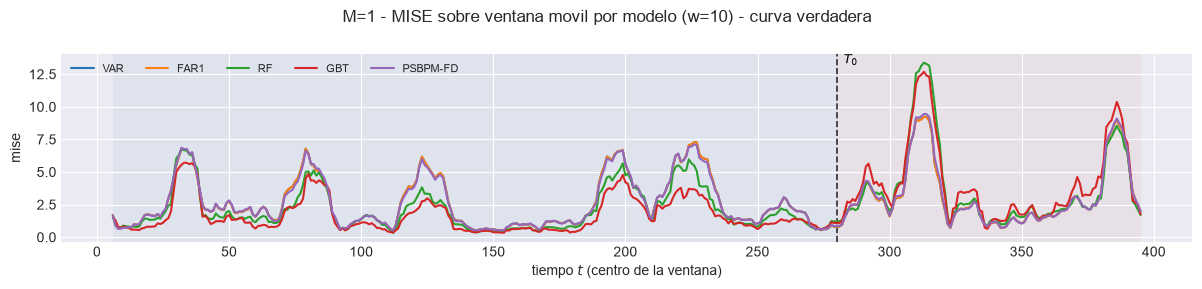

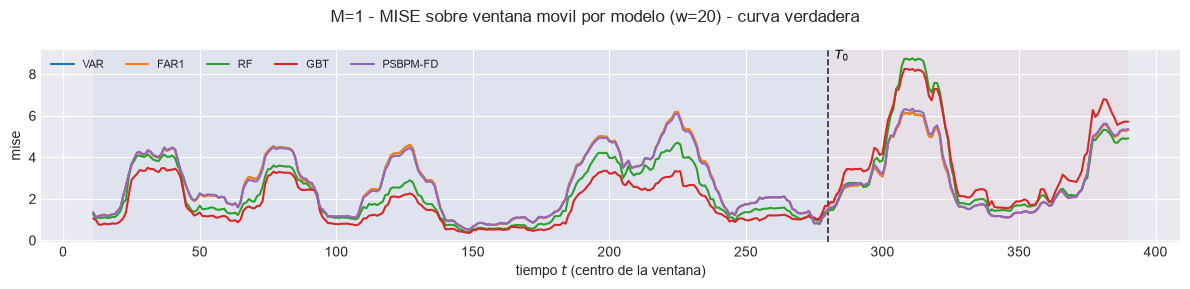

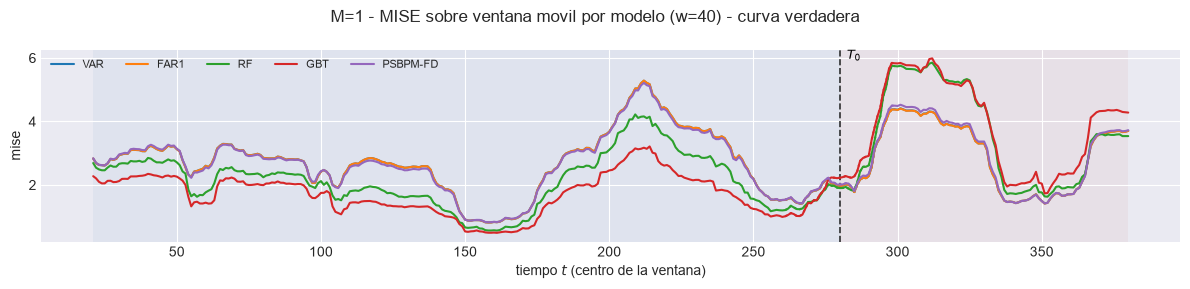

M=1 dibuja: ['FAR1', 'GBT', 'PSBPM-FD', 'RF', 'VAR']


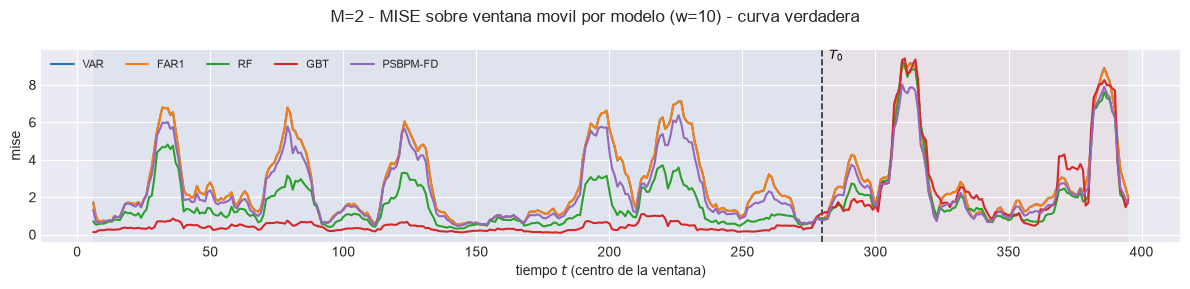

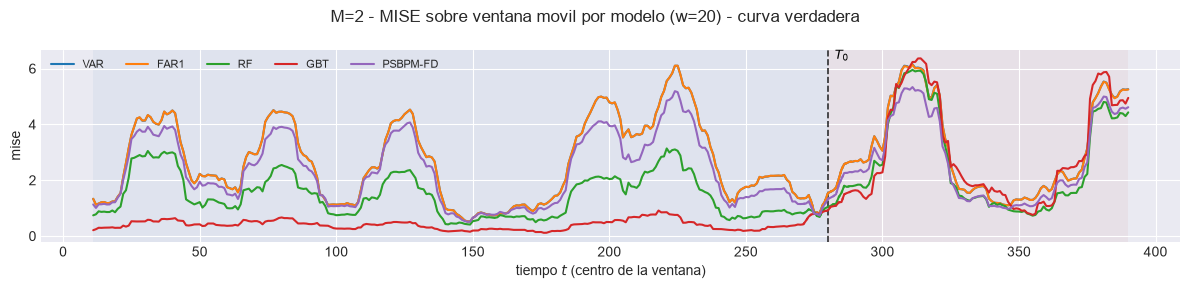

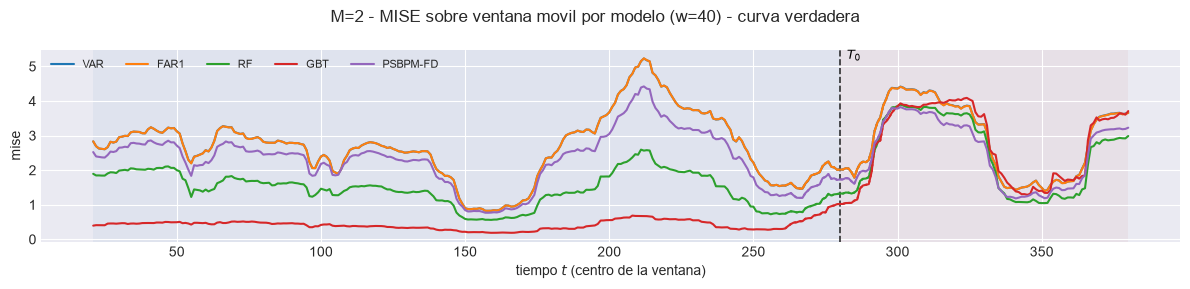

M=2 dibuja: ['FAR1', 'GBT', 'PSBPM-FD', 'RF', 'VAR']

excluidas de TODAS las figuras: ['(truncamiento FPCA)', 'media', 'persistencia'] - siguen en las tablas y en los CSV


In [19]:
# Una figura por ancho y por M, con SOLO los modelos (ver EXCLUIR_DE_FIGURA).
fuera = set(EXCLUIR_DE_FIGURA)

for M in EST:
    e = EST[M]
    for w in VENTANAS_W:
        tw = e["tablas_w"][w]
        tf = tw[~tw["modelo"].isin(fuera)].copy()
        tf.attrs["w"] = w
        plot_ventana_movil(
            tf, T0, ["mise"], columna_grupo="modelo",
            title=f"M={M} - MISE sobre ventana movil por modelo (w={w}) - "
                  "curva verdadera",
            save_path=str(e["paths"]["out_report"]
                          / f"{PREFIJO + 2}_ventana_modelos_w{w}.png"),
            verbose=False)
        plt.show()
    print(f"M={M} dibuja: "
          f"{sorted(set(e['ventana_df']['modelo'].unique()) - fuera)}")
print("\nexcluidas de TODAS las figuras:", sorted(fuera),
      "- siguen en las tablas y en los CSV")

In [20]:
# Lectura numerica del salto en T0 por modelo, excluyendo las ventanas que lo
# cruzan. Aqui SI van todas las series: en una tabla las lineas base no
# estorban y son la referencia con la que se lee el resto.
for M in EST:
    e = EST[M]
    limpio = e["ventana_df"][~e["ventana_df"]["cruza_T0"]]
    salto = (limpio.groupby(["modelo", "bloque"])["mise"].mean()
             .unstack("bloque")
             .rename(columns={"train": "MISE_train", "test": "MISE_test"}))
    salto["salto"] = salto["MISE_test"] / salto["MISE_train"]
    salto = salto.sort_values("MISE_test")
    salto.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 3}_salto_T0.csv")
    e["salto_df"] = salto

    display(salto.style.format({"MISE_train": "{:.6f}", "MISE_test": "{:.6f}",
                                "salto": "{:.2f}x"})
            .background_gradient(subset=["MISE_test"], cmap="RdYlGn_r")
            .set_caption(f"M={M} - MISE medio por bloque y salto en T0 "
                         f"(w={W_COMP}, ventanas que cruzan excluidas)"))

bloque,MISE_test,MISE_train,salto
modelo,,,
(truncamiento FPCA),0.279115,0.210912,1.32x
FAR1,3.197077,2.686824,1.19x
VAR,3.202070,2.686761,1.19x
media,3.209164,2.689335,1.19x
PSBPM-FD,3.248207,2.664713,1.22x
RF,3.809877,2.124228,1.79x
GBT,4.170321,1.690939,2.47x
persistencia,5.468925,4.994121,1.10x


bloque,MISE_test,MISE_train,salto
modelo,,,
(truncamiento FPCA),0.038093,0.028910,1.32x
RF,2.701098,1.468160,1.84x
PSBPM-FD,2.758107,2.319934,1.19x
GBT,3.081395,0.397844,7.75x
FAR1,3.179041,2.676502,1.19x
VAR,3.184363,2.676447,1.19x
media,3.209164,2.689335,1.19x
persistencia,5.624077,5.128558,1.10x


## 7. Contraste con el PSBPM-FD, dentro de cada $M$

Las cifras agregadas del modelo propuesto se leen de los CSV de `18_04`. La
que decide el eje 1 es el **MISE en el bloque de prueba**.

In [21]:
for M in EST:
    e = EST[M]
    f_s = e["paths"]["out_report"] / "50_metricas_scores.csv"
    f_f = e["paths"]["out_report"] / "51_metricas_funcionales.csv"

    psbp = {}
    if f_s.exists() and f_f.exists():
        _s = pd.read_csv(f_s, index_col=[0, 1])
        _f = pd.read_csv(f_f, index_col=0)
        for b in ("train", "test"):
            psbp[b] = {"RMSE_scores": float(_s.loc[b, "RMSE"].mean()),
                       "R2_scores":   float(_s.loc[b, "R2"].mean()),
                       "MISE":        float(_f.loc[b, "MISE"]),
                       "RMSE_func":   float(_f.loc[b, "RMSE_f"])}
        print(f"OK [M={M}] cifras del PSBPM-FD leidas de 50_/51_   "
              f"MISE test = {psbp['test']['MISE']:.6f}")
    else:
        print(f"! [M={M}] faltan 50_metricas_scores.csv y/o "
              "51_metricas_funcionales.csv. Ejecuta 18_04 para este M.")
    e["psbp"] = psbp

OK [M=1] cifras del PSBPM-FD leidas de 50_/51_   MISE test = 3.230494
OK [M=2] cifras del PSBPM-FD leidas de 50_/51_   MISE test = 2.783115


In [22]:
for M in EST:
    e = EST[M]
    if not e["psbp"]:
        continue
    filas = []
    for b in ("train", "test"):
        filas.append({"bloque": b, "modelo": "PSBPM-FD", **e["psbp"][b]})
        for nom in e["PRED"]:
            r = e["comp_df"].loc[(b, nom)]
            filas.append({"bloque": b, "modelo": nom,
                          "RMSE_scores": float(r["RMSE_scores"]),
                          "R2_scores": float(r["R2_scores"]),
                          "MISE": float(r["MISE"]),
                          "RMSE_func": float(r["RMSE_func"])})
        filas.append({"bloque": b, "modelo": "(truncamiento FPCA)",
                      "RMSE_scores": np.nan, "R2_scores": np.nan,
                      "MISE": e["MISE_TRUNC"][b], "RMSE_func": np.nan})

    final_df = pd.DataFrame(filas).set_index(["bloque", "modelo"])
    # La primera fila de cada bloque es, por construccion, la del PSBPM-FD.
    ref_bloque = final_df.groupby("bloque")["MISE"].transform(lambda s: s.iloc[0])
    final_df["MISE_rel_PSBP"] = final_df["MISE"] / ref_bloque
    final_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 4}_tabla_final.csv")
    e["final_df"] = final_df

    display(final_df.style
            .format({"RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
                     "MISE": "{:.6f}", "RMSE_func": "{:.6f}",
                     "MISE_rel_PSBP": "{:.3f}x"}, na_rep="-")
            .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
            .set_caption(f"M={M} - tabla del eje 1 · MISE contra la curva "
                         "VERDADERA · MISE_rel_PSBP < 1 significa mejor que el "
                         "PSBPM-FD"))

In [23]:
for M in EST:
    e = EST[M]
    if not e["psbp"]:
        continue
    print(f"══ M={M} ══ veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)")
    ref = e["psbp"]["test"]["MISE"]
    orden = (e["final_df"].loc["test", "MISE"]
             .drop(index=["(truncamiento FPCA)"]).sort_values())
    for i, (nom, v) in enumerate(orden.items(), 1):
        marca = "   <- PSBPM-FD" if nom == "PSBPM-FD" else ""
        print(f"  {i}. {nom:22s} MISE={v:.6f}   ({v / ref:.3f}x){marca}")

    mejores = [n for n, v in orden.items() if v < ref]
    e["rango_psbp"] = int(list(orden.index).index("PSBPM-FD")) + 1
    e["n_mejores"] = len(mejores)
    if not mejores:
        print("  El PSBPM-FD domina en MISE a todas las referencias en el test.")
    else:
        print(f"  Superan al PSBPM-FD en MISE: {', '.join(mejores)}")

    piso = e["MISE_TRUNC"]["test"] / ref
    e["piso_rel"] = float(piso)
    print(f"  El piso de truncamiento es {piso:.1%} del MISE del PSBPM-FD en test."
          + ("\n    <- la representacion domina el error; subir M rinde mas que "
             "cambiar de modelo" if piso > 0.7 else ""))
    print()

print("En el Escenario B la lectura se INVIERTE respecto de la del Escenario 1.")
print("Aqui el VAR y el FAR estan MAL especificados por construccion: su media")
print("condicional optima es la incondicional. Que empaten con ella es lo")
print("esperado; que el PSBPM-FD tambien lo haga seria el hallazgo negativo.")
print("La cifra que decide es la fraccion de la brecha lineal-oraculo recuperada,")
print("en la seccion 7.1.")

══ M=1 ══ veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)
  1. FAR1                   MISE=3.173834   (0.982x)
  2. VAR                    MISE=3.178087   (0.984x)
  3. media                  MISE=3.184461   (0.986x)
  4. PSBPM-FD               MISE=3.230494   (1.000x)   <- PSBPM-FD
  5. RF                     MISE=3.666965   (1.135x)
  6. GBT                    MISE=4.033479   (1.249x)
  7. persistencia           MISE=5.520350   (1.709x)
  Superan al PSBPM-FD en MISE: FAR1, VAR, media
  El piso de truncamiento es 8.3% del MISE del PSBPM-FD en test.

══ M=2 ══ veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)
  1. RF                     MISE=2.649814   (0.952x)
  2. PSBPM-FD               MISE=2.783115   (1.000x)   <- PSBPM-FD
  3. GBT                    MISE=3.009432   (1.081x)
  4. FAR1                   MISE=3.161544   (1.136x)
  5. VAR                    MISE=3.166061   (1.138x)
  6. media                  MISE=3.184461   (1.144x)
  7. persistencia           MIS

### 7.1 El techo del oráculo — **la tabla que da sentido a todas las demás**

En los Escenarios 1, 2 y 4 la tabla de arriba no discrimina, y la razón no es el
modelo sino el generador: la media condicional o es lineal o es constante, de
modo que el mejor predictor posible **es** el de la referencia lineal. Aquí no.

Esta sección pone cuatro cantidades en la misma escala:

| | Qué es | De dónde sale |
|---|---|---|
| **media incondicional** | no usar el pasado | modelo `media` de §3.4 |
| **mejor lineal (VAR ≡ FAR1)** | lo mejor que puede hacer la clase lineal homogénea | §3.1–3.2 |
| **PSBPM-FD** | el modelo propuesto | `18_04` |
| **oráculo** | la media condicional **verdadera** $\mathbb{E}[X_t\mid X_{t-1}]$ | `interno_media_condicional` del `.npz` |

El oráculo **no es un modelo**: usa el operador y las probabilidades de signo
del generador, que son inobservables. Es la **cota inferior** del MISE que
cualquier método puede alcanzar, y por eso se reporta como fila y no como
competidor — igual que el piso de truncamiento FPCA. Se reporta en dos
versiones: sobre la grilla y **proyectado sobre las $M$ autofunciones
retenidas**, que es la comparación justa contra modelos que sólo pueden
producir curvas de ese espacio.

Lo que el escenario predice, y lo que hay que verificar aquí:

1. **el mejor lineal empata con la media incondicional** — su MISE de prueba no
   baja apreciablemente del de aquélla;
2. **el oráculo está muy por debajo de los dos** — hay señal, y es grande;
3. **la distancia entre el lineal y el oráculo es el espacio disponible** para
   el PSBPM-FD. `fraccion_brecha_recuperada` mide cuánto de ese espacio ocupa:
   0 significa que el modelo se comporta como un lineal, 1 que alcanza el
   óptimo teórico.

Esa fracción es la cifra reportable del capítulo para este escenario, y es la
que ningún otro escenario del estudio puede producir.


In [24]:
from model_psbp_fd.pipelines import cargar_escenario
from model_psbp_fd.utils import pesos_trapezoidales

W_QUAD = pesos_trapezoidales(grilla)

ORACULO = {}
for M in EST:
    e = EST[M]
    npz = e["paths"]["raw"] / "escenario_B.npz"
    if not npz.exists():
        print(f"[M={M}] falta {npz.name}: regenerar con 18_01 "
              "(guardar_escenario con incluir_internos=True).")
        continue
    datos = cargar_escenario(str(npz))
    assert "interno_media_condicional" in datos, (
        "El .npz no trae la media condicional del generador: se guardó sin "
        "incluir_internos=True.")
    X_orc = datos["interno_media_condicional"][0][N_LAGS:]      # (n_orig, G)

    # El oráculo vive en la grilla; los modelos sólo pueden producir curvas del
    # espacio de las M autofunciones. Para que la comparación sea de PREDICCIÓN
    # y no de REPRESENTACIÓN se proyecta el oráculo sobre esa misma base. Las
    # autofunciones son ortonormales en L^2, de modo que la proyección es el
    # producto interno con la cuadratura del proyecto.
    PHI = e["Psi_grid"] if "Psi_grid" in e else e["fpca"].Psi_grid
    S_orc    = (X_orc - e["fpca"].mu_grid) @ (W_QUAD[:, None] * PHI)
    X_orc_pr = e["fpca"].mu_grid + S_orc @ PHI.T

    ORACULO[M] = pd.DataFrame([
        {"bloque": etq,
         "MISE_oraculo_grilla":     mise(X_true_ev[m], X_orc[m], grilla),
         "MISE_oraculo_proyectado": mise(X_true_ev[m], X_orc_pr[m], grilla)}
        for etq, m in (("train", es_train), ("test", ~es_train))
    ]).set_index("bloque")

    print(f"M={M}  MISE del ORÁCULO (test): grilla "
          f"{ORACULO[M].loc['test', 'MISE_oraculo_grilla']:.6f}  ·  proyectado "
          f"{ORACULO[M].loc['test', 'MISE_oraculo_proyectado']:.6f}")


def _mise_test(final_df, nombre):
    """MISE de prueba de un modelo de la tabla final, o NaN si no está."""
    try:
        return float(final_df.loc[("test", nombre), "MISE"])
    except KeyError:
        return float("nan")


filas = []
for M in EST:
    e = EST[M]
    if M not in ORACULO or "final_df" not in e:
        continue
    fd = e["final_df"]
    mise_incond = _mise_test(fd, "media")
    mise_lineal = _mise_test(fd, "VAR")
    mise_psbp   = _mise_test(fd, "PSBPM-FD")
    mise_orc    = float(ORACULO[M].loc["test", "MISE_oraculo_proyectado"])
    brecha      = mise_lineal - mise_orc
    filas.append({
        "M": M,
        "media incondicional": mise_incond,
        "mejor lineal (VAR)":  mise_lineal,
        "PSBPM-FD":            mise_psbp,
        "oráculo (proyectado)": mise_orc,
        "brecha lineal-oráculo": brecha,
        "ganancia_lineal_sobre_incondicional":
            (mise_incond - mise_lineal) / mise_incond if mise_incond else np.nan,
        "fraccion_brecha_recuperada":
            (mise_lineal - mise_psbp) / brecha if brecha > 0 else np.nan,
    })

TECHO = pd.DataFrame(filas).set_index("M")
for M in ORACULO:
    if M in TECHO.index:
        TECHO.loc[[M]].to_csv(
            EST[M]["paths"]["out_report"] / f"{PREFIJO + 6}_techo_oraculo.csv")

display(TECHO.style.format("{:.6f}", na_rep="-")
        .set_caption("Bloque de PRUEBA · el mejor lineal contra el oráculo del "
                     "generador · MISE contra la curva VERDADERA"))

print("Lectura:")
for M, r in TECHO.iterrows():
    print(f"  M={M}: el mejor lineal mejora a la media incondicional en "
          f"{r['ganancia_lineal_sobre_incondicional']:+.2%}"
          "   (se espera ~ 0: el FAR muere)")
    print(f"        brecha disponible = {r['brecha lineal-oráculo']:.6f} de MISE; "
          f"el PSBPM-FD recupera {r['fraccion_brecha_recuperada']:.1%}")
print("\nUna ganancia del lineal cercana a cero CON una brecha grande es la firma "
      "del escenario:\nhay señal y la clase lineal no puede tocarla. Si además la "
      "fracción recuperada es\ngrande, es la primera evidencia positiva en media "
      "condicional del estudio.")


M=1  MISE del ORÁCULO (test): grilla 2.087129  ·  proyectado 2.094025
M=2  MISE del ORÁCULO (test): grilla 2.087129  ·  proyectado 2.087768


,media incondicional,mejor lineal (VAR),PSBPM-FD,oráculo (proyectado),brecha lineal-oráculo,ganancia_lineal_sobre_incondicional,fraccion_brecha_recuperada
M,,,,,,,
1,3.184461,3.178087,3.230494,2.094025,1.084061,0.002002,-0.048343
2,3.184461,3.166061,2.783115,2.087768,1.078293,0.005778,0.355141


Lectura:
  M=1: el mejor lineal mejora a la media incondicional en +0.20%   (se espera ~ 0: el FAR muere)
        brecha disponible = 1.084061 de MISE; el PSBPM-FD recupera -4.8%
  M=2: el mejor lineal mejora a la media incondicional en +0.58%   (se espera ~ 0: el FAR muere)
        brecha disponible = 1.078293 de MISE; el PSBPM-FD recupera 35.5%

Una ganancia del lineal cercana a cero CON una brecha grande es la firma del escenario:
hay señal y la clase lineal no puede tocarla. Si además la fracción recuperada es
grande, es la primera evidencia positiva en media condicional del estudio.


## 8. El barrido: todos los modelos contra $M$

Ésta es la sección que el barrido hace posible, y la que decide entre las dos
explicaciones que un solo $M$ no distingue.

**Todos los competidores viven sobre la misma representación FPCA.** Por eso, si
al subir $M$ el MISE de prueba se degrada en el VAR, el FAR(1), el RF y el
PSBPM-FD por igual, el responsable es la **representación** —componentes de
varianza baja que el estandarizador amplifica hasta volverlas ruido con la
misma escala que la señal— y no el modelo propuesto. Si en cambio la
degradación es **específica del PSBPM-FD**, queda respaldado el mecanismo de la
Etapa D: $M$ entra dos veces, y su segunda entrada —$p=qM$ covariables en la
regresión probit de pesos **compartidos entre átomos**— diluye el prior de
selección y estropea la asignación de la mezcla también para las componentes
buenas.

La cifra que separa ambas cosas es la **razón `MISE_modelo / MISE_VAR`** dentro
de cada $M$: normaliza por lo que la representación le hace a todo el mundo, y
deja a la vista sólo la parte diferencial.

In [25]:
filas = []
for M in EST:
    e = EST[M]
    for bloque in ("train", "test"):
        for nom in MODELOS + ["(truncamiento FPCA)"]:
            r = e["comp_df"].loc[(bloque, nom)]
            filas.append({
                "M": M, "bloque": bloque, "modelo": nom,
                "MISE": float(r["MISE"]),
                "RMSE_func": float(r["RMSE_func"]),
                "RMSE_scores": float(r["RMSE_scores"]),
                "R2_scores": float(r["R2_scores"]),
            })
        if e["psbp"]:
            p = e["psbp"][bloque]
            filas.append({
                "M": M, "bloque": bloque, "modelo": "PSBPM-FD",
                "MISE": p["MISE"], "RMSE_func": p["RMSE_func"],
                "RMSE_scores": p["RMSE_scores"], "R2_scores": p["R2_scores"],
            })

modelos_M = pd.DataFrame(filas)

# Razon contra el VAR DENTRO de cada (M, bloque): normaliza por lo que la
# representacion le hace a todos por igual.
_var = (modelos_M[modelos_M.modelo == "VAR"]
        .set_index(["M", "bloque"])["MISE"].rename("MISE_VAR"))
modelos_M = modelos_M.join(_var, on=["M", "bloque"])
modelos_M["MISE_rel_VAR"] = modelos_M["MISE"] / modelos_M["MISE_VAR"]
modelos_M.to_csv(PATH_BARRIDO / "90_comparacion_modelos_por_M.csv", index=False)

piv_mise = (modelos_M[modelos_M.bloque == "test"]
            .pivot(index="modelo", columns="M", values="MISE"))
display(piv_mise.style.format("{:.6f}", na_rep="-")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("MISE en el bloque de PRUEBA · filas = modelo, "
                     "columnas = M · menor es mejor"))

M,1,2
modelo,,
(truncamiento FPCA),0.269540,0.036994
FAR1,3.173834,3.161544
GBT,4.033479,3.009432
PSBPM-FD,3.230494,2.783115
RF,3.666965,2.649814
VAR,3.178087,3.166061
media,3.184461,3.184461
persistencia,5.520350,5.679458


In [26]:
piv_rel = (modelos_M[modelos_M.bloque == "test"]
           .pivot(index="modelo", columns="M", values="MISE_rel_VAR"))
display(piv_rel.style.format("{:.3f}", na_rep="-")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("MISE relativo al VAR dentro de cada M (test) · el VAR es "
                     "1.000 por construcción · > 1 significa peor que el VAR"))

print("Lectura: una fila que crece con M mientras las demás se mantienen es una")
print("degradación ESPECÍFICA de ese modelo. Si crecen todas a la vez, lo que")
print("se degrada es la representación y no el modelo.")

M,1,2
modelo,,
(truncamiento FPCA),0.085,0.012
FAR1,0.999,0.999
GBT,1.269,0.951
PSBPM-FD,1.016,0.879
RF,1.154,0.837
VAR,1.000,1.000
media,1.002,1.006
persistencia,1.737,1.794


Lectura: una fila que crece con M mientras las demás se mantienen es una
degradación ESPECÍFICA de ese modelo. Si crecen todas a la vez, lo que
se degrada es la representación y no el modelo.


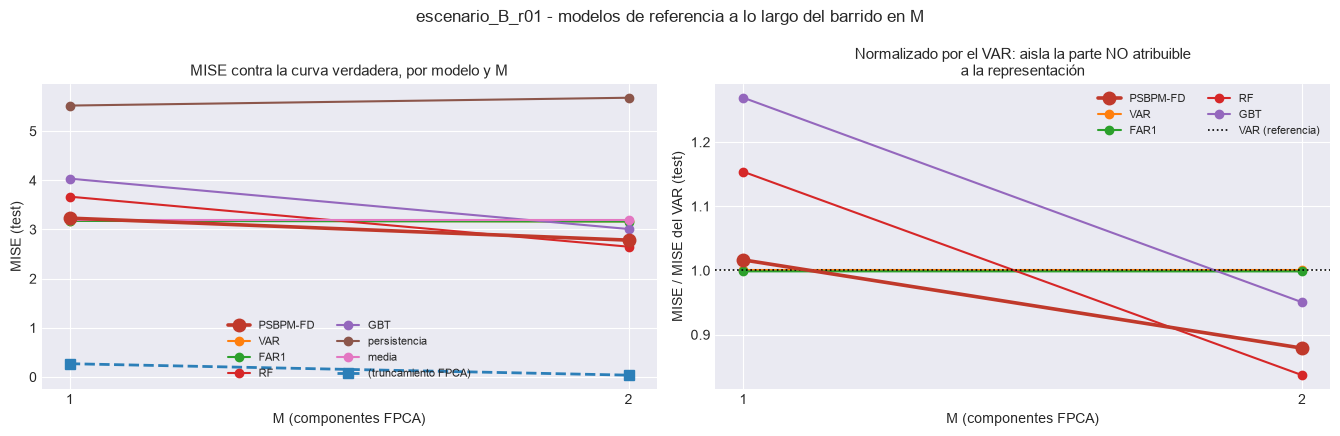

In [27]:
# Figura del barrido: MISE de test por modelo contra M, en escala absoluta y
# relativa al VAR. Las lineas base y el piso van en el panel absoluto porque
# ahi son la referencia, y fuera del relativo porque lo comprimen.
te = modelos_M[modelos_M.bloque == "test"]
_Ms = sorted(te["M"].unique())
# En §8 las lineas base y el piso SI van en el panel absoluto -ahi son la
# referencia con la que se lee todo lo demas-, asi que de EXCLUIR_DE_FIGURA
# solo se hereda lo que sobra por DUPLICAR a otro modelo, hoy el FAR1.
_REDUNDANTES = EXCLUIR_DE_FIGURA - {"media", "persistencia", "(truncamiento FPCA)"}
_orden = [m for m in ["PSBPM-FD", "VAR", "FAR1", "RF", "GBT",
                      "persistencia", "media", "(truncamiento FPCA)"]
          if m in set(te["modelo"]) and m not in _REDUNDANTES]
if _REDUNDANTES:
    print(f"fuera de la figura por redundantes: {sorted(_REDUNDANTES)}"
          "   (siguen en las tablas de arriba)")
_estilo = {"PSBPM-FD": dict(color="#c0392b", lw=2.6, ms=9, marker="o", zorder=5),
           "(truncamiento FPCA)": dict(color="#2c7fb8", lw=2.0, ms=7,
                                       marker="s", ls="--")}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax = axes[0]
for i, nom in enumerate(_orden):
    s = te[te.modelo == nom].set_index("M")["MISE"].reindex(_Ms)
    kw = _estilo.get(nom, dict(color=plt.cm.tab10(i % 10), lw=1.5, ms=6,
                               marker="o"))
    ax.plot(_Ms, s.to_numpy(), label=nom, **kw)
ax.set_ylabel("MISE (test)")
ax.set_title("MISE contra la curva verdadera, por modelo y M", fontsize=11)
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for i, nom in enumerate(_orden):
    if nom in ("media", "persistencia", "(truncamiento FPCA)"):
        continue
    s = te[te.modelo == nom].set_index("M")["MISE_rel_VAR"].reindex(_Ms)
    kw = _estilo.get(nom, dict(color=plt.cm.tab10(i % 10), lw=1.5, ms=6,
                               marker="o"))
    ax.plot(_Ms, s.to_numpy(), label=nom, **kw)
ax.axhline(1.0, color="k", ls=":", lw=1.2, label="VAR (referencia)")
ax.set_ylabel("MISE / MISE del VAR (test)")
ax.set_title("Normalizado por el VAR: aisla la parte NO atribuible\n"
             "a la representación", fontsize=11)
ax.legend(fontsize=8, ncol=2)

for ax in axes:
    ax.set_xticks(_Ms); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} - modelos de referencia a lo largo del "
             "barrido en M", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "91_mise_modelos_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Ranking por M: en que puesto queda el PSBPM-FD dentro de cada punto del
# barrido, y contra cuantos pierde. Es la lectura del eje 1 resumida a dos
# numeros por M.
filas_r = []
for M in EST:
    e = EST[M]
    if not e["psbp"]:
        continue
    orden = (e["final_df"].loc["test", "MISE"]
             .drop(index=["(truncamiento FPCA)"]).sort_values())
    filas_r.append({
        "M": M,
        "puesto_PSBPM": e["rango_psbp"],
        "de_n_modelos": int(len(orden)),
        "n_que_lo_superan": e["n_mejores"],
        "MISE_PSBPM": float(e["psbp"]["test"]["MISE"]),
        "MISE_mejor": float(orden.iloc[0]),
        "mejor_modelo": str(orden.index[0]),
        "MISE_VAR": float(e["comp_df"].loc[("test", "VAR"), "MISE"]),
        "MISE_truncamiento": float(e["MISE_TRUNC"]["test"]),
        "piso_sobre_PSBPM": e["piso_rel"],
        "far_hs": e["far_hs"], "far_hs_referencia": HS_REFERENCIA,
        "var_explicada": e["var_explicada"],
    })

ranking_df = pd.DataFrame(filas_r).set_index("M")
ranking_df.to_csv(PATH_BARRIDO / "92_ranking_por_M.csv")

display(ranking_df.style
        .format({"MISE_PSBPM": "{:.6f}", "MISE_mejor": "{:.6f}",
                 "MISE_VAR": "{:.6f}", "MISE_truncamiento": "{:.6f}",
                 "piso_sobre_PSBPM": "{:.1%}", "far_hs": "{:.4f}",
                 "var_explicada": "{:.4%}"}, na_rep="-")
        .set_caption("Posición del PSBPM-FD dentro de cada punto del barrido "
                     "(bloque de prueba, MISE)"))

,puesto_PSBPM,de_n_modelos,n_que_lo_superan,MISE_PSBPM,MISE_mejor,mejor_modelo,MISE_VAR,MISE_truncamiento,piso_sobre_PSBPM,far_hs,far_hs_referencia,var_explicada
M,,,,,,,,,,,,
1,4,7,3,3.230494,3.173834,FAR1,3.178087,0.269540,8.3%,0.0202,0.70,91.7332%
2,2,7,1,2.783115,2.649814,RF,3.166061,0.036994,1.3%,0.2040,0.70,98.9376%


In [29]:
# == Resumen ejecutable, uno por M ===========================================
partes = []
for M in EST:
    e = EST[M]
    resumen = {
        "M": M,
        "experiment_id": e["eid"],
        "objetivo_evaluacion": OBJETIVO,
        "modo_residuo": MODO_RESIDUO,
        "n_lags": N_LAGS, "M_fpca": e["M_fpca"], "K_base": e["K"],
        "var_explicada": round(e["var_explicada"], 6),
        "n_train_origenes": int(es_train.sum()),
        "n_test_origenes": int((~es_train).sum()),
        "w_ventana": W_COMP,
        "p_bic_libre": int(e["p_bic"]),
        "far_hs_norm": round(e["far_hs"], 6),
        "far_hs_referencia": HS_REFERENCIA,
        "far_radio_espectral": round(e["far_rho"], 6),
        "mise_truncamiento_test": round(float(e["MISE_TRUNC"]["test"]), 8),
        **{f"mise_test_{n}": round(float(e["comp_df"].loc[("test", n), "MISE"]), 8)
           for n in e["PRED"]},
    }
    if e["psbp"]:
        resumen["mise_test_PSBPM-FD"] = round(e["psbp"]["test"]["MISE"], 8)

    pd.Series(resumen).to_csv(
        e["paths"]["out_report"] / f"{PREFIJO + 5}_resumen_comparacion.csv",
        header=False)
    partes.append(resumen)

    print(f"── M={M} ──")
    for k, v in resumen.items():
        print(f"  {k:26s}: {v}")
    print("  parametros declarados de cada competidor:")
    for n, txt in e["INFO"].items():
        print(f"    {n:14s}: {txt}")
    print()

resumen_M = pd.DataFrame(partes).set_index("M")
resumen_M.to_csv(PATH_BARRIDO / "93_resumen_comparacion_por_M.csv")
print(f"Por M: {[str(EST[M]['paths']['out_report']) for M in EST]}")
print(f"       (archivos {PREFIJO}-{PREFIJO + 5})")
print(f"Barrido: {PATH_BARRIDO}   (archivos 90-93)")

── M=1 ──
  M                         : 1
  experiment_id             : escenario_B_r01_m01
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  n_lags                    : 1
  M_fpca                    : 1
  K_base                    : 4
  var_explicada             : 0.917332
  n_train_origenes          : 279
  n_test_origenes           : 120
  w_ventana                 : 20
  p_bic_libre               : 1
  far_hs_norm               : 0.020199
  far_hs_referencia         : 0.70
  far_radio_espectral       : 0.020199
  mise_truncamiento_test    : 0.2695401
  mise_test_VAR             : 3.17808667
  mise_test_FAR1            : 3.17383406
  mise_test_RF              : 3.66696502
  mise_test_GBT             : 4.03347905
  mise_test_media           : 3.18446135
  mise_test_persistencia    : 5.52034976
  mise_test_PSBPM-FD        : 3.23049361
  parametros declarados de cada competidor:
    VAR           : p=1, 2 parametros
    FAR1          : K=1, ||Psi||_H

In [30]:
# == Veredicto del barrido ===================================================
print("=" * 72)
print(f"  BARRIDO {EXPERIMENT_BASE}   ·   M evaluados: {sorted(EST)}")
print("=" * 72)

if "PSBPM-FD" in set(te["modelo"]):
    s_ps  = te[te.modelo == "PSBPM-FD"].set_index("M")["MISE_rel_VAR"].reindex(_Ms)
    otros = [m for m in _orden
             if m not in ("PSBPM-FD", "media", "persistencia",
                          "(truncamiento FPCA)")]
    print(f"  MISE relativo al VAR (test), por M:")
    for M in _Ms:
        fila = "   ".join(
            f"{m}={te[(te.modelo == m) & (te.M == M)]['MISE_rel_VAR'].iloc[0]:.3f}"
            for m in ["PSBPM-FD"] + otros
            if not te[(te.modelo == m) & (te.M == M)].empty)
        print(f"    M={M}:  {fila}")

    if len(_Ms) >= 2:
        d_ps = np.diff(s_ps.to_numpy())
        d_ot = np.mean([np.diff(te[te.modelo == m].set_index("M")["MISE_rel_VAR"]
                                .reindex(_Ms).to_numpy())
                        for m in otros], axis=0) if otros else None
        print("-" * 72)
        print(f"  cambio de MISE_rel_VAR del PSBPM-FD: "
              + "  ".join(f"{_Ms[i]}->{_Ms[i+1]}: {d:+.4f}"
                          for i, d in enumerate(d_ps)))
        if d_ot is not None:
            print(f"  ídem promediado sobre los otros competidores: "
                  + "  ".join(f"{_Ms[i]}->{_Ms[i+1]}: {d:+.4f}"
                              for i, d in enumerate(d_ot)))
            if np.all(d_ps > 0) and d_ot is not None and np.all(d_ps > d_ot):
                print("\n  El PSBPM-FD se degrada con M MÁS que sus competidores")
                print("  sobre la misma representación: la degradación NO es de la")
                print("  representación. Es la hipótesis de la Etapa D -M entra")
                print("  dos veces, y la segunda diluye el prior de selección de")
                print("  los pesos, compartidos entre átomos-.")
            elif np.all(d_ps > 0):
                print("\n  Todos se degradan con M: el responsable es la")
                print("  REPRESENTACIÓN -componentes de varianza baja que el")
                print("  estandarizador amplifica hasta la escala de la señal-,")
                print("  no el modelo propuesto. Se reporta como limitación de la")
                print("  reducción de dimensión, no como fallo del PSBPM-FD.")
            else:
                print("\n  La degradación no es monótona: con R=1 una diferencia")
                print("  del 2-3% en MISE es indistinguible del ruido Monte Carlo.")
                print("  La conclusión necesita las réplicas de la Etapa D.")
else:
    print("  Sin cifras del PSBPM-FD: ejecuta 18_04 para los M del barrido.")

print("=" * 72)
print("AVISO con R=1 ninguna diferencia del orden del 2-3% entre modelos es")
print("concluyente. El barrido en M identifica la DIRECCIÓN del efecto; su")
print("magnitud necesita las réplicas Monte Carlo de la Etapa D.")

  BARRIDO escenario_B_r01   ·   M evaluados: [1, 2]
  MISE relativo al VAR (test), por M:
    M=1:  PSBPM-FD=1.016   VAR=1.000   FAR1=0.999   RF=1.154   GBT=1.269
    M=2:  PSBPM-FD=0.879   VAR=1.000   FAR1=0.999   RF=0.837   GBT=0.951
------------------------------------------------------------------------
  cambio de MISE_rel_VAR del PSBPM-FD: 1->2: -0.1374
  ídem promediado sobre los otros competidores: 1->2: -0.1589

  La degradación no es monótona: con R=1 una diferencia
  del 2-3% en MISE es indistinguible del ruido Monte Carlo.
  La conclusión necesita las réplicas de la Etapa D.
AVISO con R=1 ninguna diferencia del orden del 2-3% entre modelos es
concluyente. El barrido en M identifica la DIRECCIÓN del efecto; su
magnitud necesita las réplicas Monte Carlo de la Etapa D.
